In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch import nn
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

/Users/Mourya/miniforge3/envs/aircraft-conflict-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.


In [2]:
train_graphs = torch.load(
    "processed_data/train_graphs.pt",
    weights_only=False
)

val_graphs = torch.load(
    "processed_data/val_graphs.pt",
    weights_only=False
)

test_graphs = torch.load(
    "processed_data/test_graphs.pt",
    weights_only=False
)

print("Train:", len(train_graphs))
print("Validation:", len(val_graphs))
print("Test:", len(test_graphs))

Train: 504
Validation: 108
Test: 108


In [4]:
train_loader = DataLoader(
    train_graphs,
    batch_size=8,
    shuffle=False
)

val_loader = DataLoader(
    val_graphs,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=8,
    shuffle=False
)

print("DataLoaders ready.")

DataLoaders ready.


In [5]:
from pathlib import Path

print("GAT model exists:",
      Path("models/conflict_gat_large_best.pth").exists())

print("GCN model exists:",
      Path("models/conflict_gcn.pth").exists())

GAT model exists: True
GCN model exists: True


In [6]:
from torch import nn
from torch_geometric.nn import GATConv
import torch.nn.functional as F

class ConflictGAT(nn.Module):

    def __init__(self,
                 node_dim=6,
                 edge_dim=5,
                 hidden_dim=64,
                 heads=4):

        super().__init__()

        self.gat1 = GATConv(
            node_dim,
            hidden_dim,
            heads=heads,
            concat=True
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False
        )

        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, data):

        x = F.elu(self.gat1(data.x, data.edge_index))
        x = self.gat2(x, data.edge_index)

        src = x[data.edge_index[0]]
        dst = x[data.edge_index[1]]

        edge_input = torch.cat(
            [src, dst, data.edge_attr],
            dim=1
        )

        return self.edge_mlp(edge_input).squeeze(-1)

In [8]:
from torch import nn
from torch_geometric.nn import GATConv
import torch.nn.functional as F

class ConflictGAT(nn.Module):

    def __init__(self):

        super().__init__()

        self.gat1 = GATConv(
            6,
            64,
            heads=2,
            concat=True
        )

        self.gat2 = GATConv(
            128,
            64,
            heads=1,
            concat=False
        )

        self.edge_mlp = nn.Sequential(
            nn.Linear(64*2 + 5, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self,data):

        x = F.elu(self.gat1(data.x,data.edge_index))
        x = self.gat2(x,data.edge_index)

        src = x[data.edge_index[0]]
        dst = x[data.edge_index[1]]

        edge_input = torch.cat(
            [src,dst,data.edge_attr],
            dim=1
        )

        return self.edge_mlp(edge_input).squeeze(-1)

In [10]:
state = torch.load(
    "models/conflict_gat_large_best.pth",
    map_location="cpu",
    weights_only=False
)

for k, v in state.items():
    print(k, tuple(v.shape))

gat1.att_src (1, 2, 64)
gat1.att_dst (1, 2, 64)
gat1.att_edge (1, 2, 64)
gat1.bias (128,)
gat1.lin.weight (128, 6)
gat1.lin_edge.weight (128, 5)
gat2.att_src (1, 1, 64)
gat2.att_dst (1, 1, 64)
gat2.att_edge (1, 1, 64)
gat2.bias (64,)
gat2.lin.weight (64, 128)
gat2.lin_edge.weight (64, 5)
edge_mlp.0.weight (64, 133)
edge_mlp.0.bias (64,)
edge_mlp.2.weight (1, 64)
edge_mlp.2.bias (1,)


In [11]:
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class ConflictGAT(nn.Module):

    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=6,
            out_channels=64,
            heads=2,
            concat=True,
            edge_dim=5
        )

        self.gat2 = GATConv(
            in_channels=128,
            out_channels=64,
            heads=1,
            concat=False,
            edge_dim=5
        )

        self.edge_mlp = nn.Sequential(
            nn.Linear(64*2 + 5, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self,data):

        x = F.elu(
            self.gat1(
                data.x,
                data.edge_index,
                data.edge_attr
            )
        )

        x = self.gat2(
            x,
            data.edge_index,
            data.edge_attr
        )

        src = x[data.edge_index[0]]
        dst = x[data.edge_index[1]]

        edge_input = torch.cat(
            [src,dst,data.edge_attr],
            dim=1
        )

        return self.edge_mlp(edge_input).squeeze(-1)

In [12]:
device = torch.device("cpu")

gat_model = ConflictGAT().to(device)

state = torch.load(
    "models/conflict_gat_large_best.pth",
    map_location=device,
    weights_only=False
)

gat_model.load_state_dict(state)

gat_model.eval()

print("✅ GAT loaded successfully")

✅ GAT loaded successfully


In [13]:
from sklearn.metrics import roc_auc_score

gat_model.eval()

y_true = []
y_prob = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        logits = gat_model(batch)

        probs = torch.sigmoid(logits)

        y_true.extend(batch.y.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

print("Samples:", len(y_true))
print("Positive labels:", y_true.sum())
print("ROC-AUC:", roc_auc_score(y_true, y_prob))

Samples: 134646
Positive labels: 30
ROC-AUC: 0.9922032546898835


In [14]:
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    precision = precision_score(
        y_true,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        pred,
        zero_division=0
    )

    results.append(
        [t, precision, recall, f1]
    )

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_results.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
98,0.99,0.038095,0.533333,0.071111
97,0.98,0.037453,0.666667,0.070922
96,0.97,0.037157,0.766667,0.070878
95,0.96,0.033141,0.766667,0.063536
94,0.95,0.030303,0.766667,0.058302
92,0.93,0.029940,0.833333,0.057803
93,0.94,0.029851,0.800000,0.057554
91,0.92,0.028506,0.833333,0.055127
90,0.91,0.026969,0.833333,0.052247
89,0.90,0.026123,0.833333,0.050659


In [15]:
threshold_results.to_csv(
    "../processed_data/gat_threshold_analysis.csv",
    index=False
)

print("Saved.")

Saved.


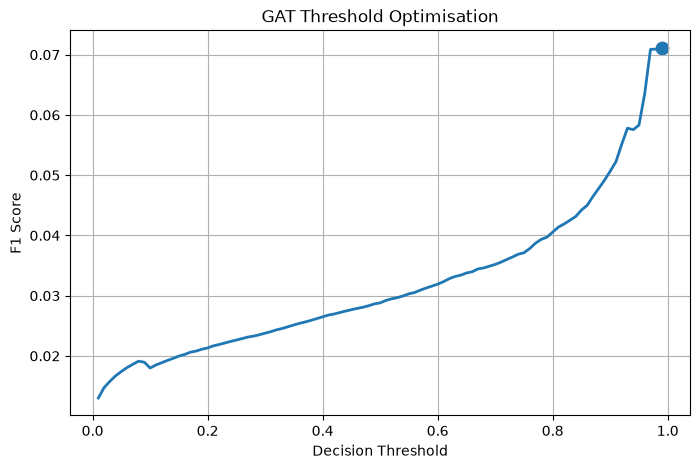

Threshold    0.990000
Precision    0.038095
Recall       0.533333
F1           0.071111
Name: 98, dtype: float64


In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    linewidth=2
)

best = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

plt.scatter(
    best["Threshold"],
    best["F1"],
    s=80
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("GAT Threshold Optimisation")

plt.grid(True)

plt.show()

print(best)